In [1]:
import sys
from pathlib import Path

import matplotlib as mpl

In [2]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [3]:
import src.compute.stats as stats_module
# from data import b_naive, b_memory

import importlib
import src.plot.tracks.reconstruct as reconstruct_module
import src.batch.tree as batch_tree_module
import src.io.load as load_module
import src.filter.filters as filters_module

In [4]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\mem_cxcl12\#memory-cxcl12#BC39#Stablized_spots.csv", retain=['POSITION_Z'], split_filename=True, split_filename_delimiter='#', split_filename_position=2)

In [5]:
importlib.reload(stats_module)

stats = stats_module.stats

spots = stats.spots(data)
spots

,track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set,frame,distance,cum_track_length,cum_track_displacement,...,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
track_uid,,,,,,,,,,,,,,,,,,,,,
0,196.0,0.0,446.049935,514.718016,0.0,BC39,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,46.0,0.0,105.142437,265.404884,0.0,BC39,0,422.344599,4.223446e+02,422.344599,...,NaN,3.519538,NaN,-2.510153,NaN,NaN,NaN,NaN,-2.510153,0.000000
0,193.0,0.0,57.339646,514.234949,0.0,BC39,0,253.380165,6.757248e+02,388.710589,...,NaN,2.159503,NaN,1.760594,115.304209,1.153042e+02,115.304209,0.640579,2.766813,0.464941
0,199.0,0.0,533.838219,533.021939,0.0,BC39,0,476.868789,1.152594e+03,89.676176,...,NaN,0.373651,NaN,0.039407,98.616773,2.139210e+02,106.960491,0.445669,1.562946,0.856285
0,198.0,0.0,962.196674,538.272284,0.0,BC39,0,428.390630,1.580984e+03,516.683907,...,NaN,1.722280,NaN,0.012256,1.555608,2.154766e+02,71.825530,0.239418,0.416118,0.725771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,723.0,3540.0,11.838741,321.551650,0.0,BC39,59,399.540816,1.219409e+07,475.239524,...,3444.657704,0.000326,9.455563e-08,2.625023,25.926157,2.900973e+06,119.303046,0.000082,-2.235701,0.996397
0,727.0,3540.0,41.932501,675.383134,0.0,BC39,59,355.108932,1.219444e+07,434.884100,...,3444.758017,0.000298,8.652027e-08,1.485949,65.264125,2.901038e+06,119.300824,0.000082,-2.242017,0.996432
0,726.0,3540.0,17.251840,588.025299,0.0,BC39,59,90.777345,1.219453e+07,435.019268,...,3444.783661,0.000298,8.654295e-08,-1.846144,169.085126,2.901207e+06,119.302871,0.000082,-2.237620,0.996394


In [6]:
importlib.reload(stats_module)

stats = stats_module.stats

tracks = stats.tracks(spots)
tracks

,set,track_id,POSITION_Z,track_length,speed_min,speed_max,speed_mean,speed_sd,speed_median,x_location,...,track_end_time,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_displacement,straightness_ratio,track_points
track_uid,,,,,,,,,,,,,,,,,,,,,
0,BC39,196.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,46.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,193.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,199.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,198.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,BC39,727.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,723.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322
0,BC39,730.0,0.0,1.219479e+07,0.108514,22.093806,8.356832,4.293356,8.060981,470.788405,...,3540.0,0.000326,9.473861e-08,-2.224339,0.996328,119.294019,0.000082,476.264969,0.000039,24322


In [8]:
importlib.reload(filters_module)

filter = filters_module.filter

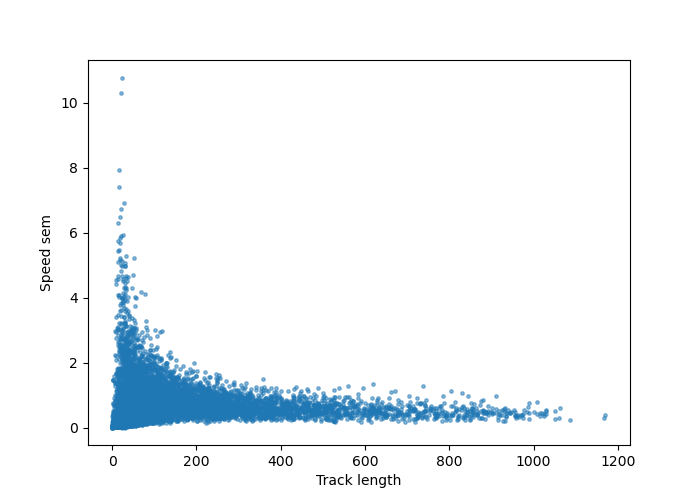

IndexError: pop from empty list

In [19]:
%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\Track stats 2026-02-22.csv")

x = df["Track length"].to_numpy(float)
y = df["Speed sem"].to_numpy(float)
xy = np.column_stack([x, y])

fig, ax = plt.subplots(figsize=(7, 5))
pts = ax.scatter(x, y, s=6, alpha=0.5)
ax.set_xlabel("Track length")
ax.set_ylabel("Speed sem")

# store selection so you can use it in later cells
selection = {"mask": None, "verts": None}

def on_select(verts):
    path = Path(verts)
    inside = path.contains_points(xy)
    pts.set_color(np.where(inside, "red", "C0"))
    fig.canvas.draw_idle()
    selection["mask"] = inside
    selection["verts"] = verts
    print(f"{inside.sum()} points inside gate")

# keep a reference on fig so it survives across cells
fig._poly_selector = PolygonSelector(ax, on_select, useblit=True)

plt.show()

In [16]:
gated = df[selection["mask"]]
gated

,Condition,Replicate,Track ID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed sem,Speed median,Speed q25,Speed q75,Speed ci95 low,Speed ci95 high,Track displacement,Straightness index,Track points,Direction mean,Direction var
15,naive-ctr,BC39,15.0,249.105784,0.038030,19.559088,4.222132,6.556429,0.853574,0.491321,0.252029,5.649649,2.761761,6.009893,199.788582,0.802023,60,-0.786704,0.823506
39,naive-ctr,BC39,39.0,256.036751,2.116670,12.678470,7.530493,3.039914,0.521341,7.081034,5.047556,10.398506,6.616082,8.488859,136.649082,0.533709,35,-0.943603,0.535815
41,naive-ctr,BC39,41.0,175.114409,9.962140,18.332266,14.592867,2.419742,0.698519,15.261788,13.188067,16.005714,13.076718,15.730249,143.058206,0.816941,13,-1.706969,0.173303
47,naive-ctr,BC39,47.0,269.823222,3.879306,18.741323,14.990179,3.150416,0.742560,15.018640,14.605301,16.816312,11.954726,15.921711,206.718778,0.766127,19,-0.919806,0.272991
55,naive-ctr,BC39,55.0,270.004693,14.124019,18.161797,16.875293,1.273939,0.318485,17.395045,16.176459,17.857202,16.158626,17.353277,182.795315,0.677008,17,-3.013200,0.325036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6218,naive-mu,BC42 (fresh),433.0,129.123599,0.744214,11.072976,7.173533,3.413152,0.804488,8.325045,4.443192,9.923447,5.357152,8.467066,111.037706,0.859933,19,1.238554,0.182203
6228,naive-mu,BC42 (fresh),443.0,173.845394,1.433868,14.832843,7.902063,2.948671,0.628659,8.028208,6.230236,8.975209,6.665892,9.124230,80.402893,0.462497,23,2.137690,0.469818
6229,naive-mu,BC42 (fresh),444.0,214.484020,3.516427,13.715733,9.749274,2.871880,0.612287,10.217018,8.100717,11.886795,8.421211,10.936605,83.343697,0.388578,23,-0.573707,0.669555
6232,naive-mu,BC42 (fresh),447.0,142.444415,1.246171,10.296142,6.474746,3.077271,0.656076,7.233264,3.459851,8.967720,4.977162,7.555207,41.643971,0.292352,23,2.019431,0.553796
